# 3-axis slicer

## Load STL

225706 triangles
Bounding box: [-29.176 -15.502   0.   ] to [30.825 15.502 48.   ]


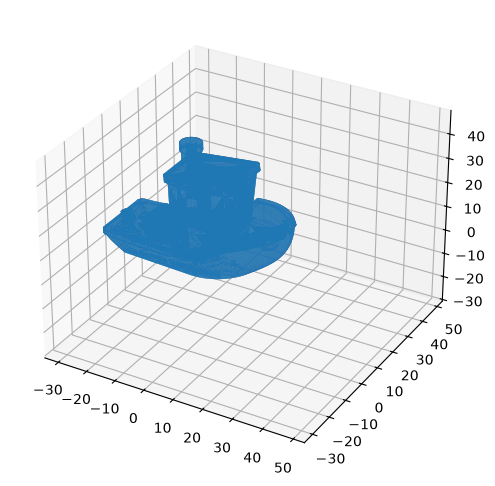

In [64]:
from stl import mesh
from matplotlib import pyplot
from mpl_toolkits import mplot3d
import numpy as np

file = 'stl/benchy.stl'

model = mesh.Mesh.from_file(file)

# Inspect
print(f'{len(model)} triangles')
print(f'Bounding box: {model.min_} to {model.max_}')

figure = pyplot.figure(figsize=(8, 6))
axes = figure.add_subplot(projection='3d')

axes.add_collection3d(mplot3d.art3d.Poly3DCollection(model.vectors))
scale = model.points.flatten()
axes.auto_scale_xyz(scale, scale, scale)


pyplot.show()


## Parameters

In [65]:
LAYER_HEIGHT = 0.5
WALL_LINES = 4
WALL_THICKNESS = 0.4
OUTER_WALL_OFFSET = WALL_THICKNESS / 2
INFILL = 0.6
TOP_LAYERS = 3
BOTTOM_LAYERS = 3
TOP_LAYER_THICKNESS = 0.4
BOTTOM_LAYER_THICKNESS = 0.4

## Slice the model

In [66]:
# shapely function to generate contours
# used for initial wall offset and inner wall offset

from shapely.geometry import LineString, Polygon
from shapely import union
from shapely.ops import polygonize, unary_union


def offset_contours(contours, offset_distance, join_style="mitre"):
    """Return all filled contour rings after one inward material offset."""
    lines = []
    z = None

    for contour in contours:
        points = np.asarray(
            contour.get_points() if hasattr(contour, "get_points") else contour
        )
        if points.ndim != 2 or points.shape[0] < 4 or points.shape[1] < 2:
            raise ValueError("Each contour must contain at least four 2D/3D points.")

        xy = points[:, :2]
        if not np.allclose(xy[0], xy[-1]):
            xy = np.vstack([xy, xy[0]])

        # Remove repeated consecutive vertices from meshcut output.
        if len(xy) > 1:
            keep = np.r_[True, np.any(np.diff(xy, axis=0) != 0, axis=1)]
            xy = xy[keep]
        if len(xy) < 4:
            continue

        lines.append(LineString(xy))
        if z is None and points.shape[1] >= 3:
            z = points[0, 2]

    if not lines:
        return []

    # Repair minor self-touching or duplicate-edge issues before testing
    # containment. polygonize() below still controls the final filled result.
    ring_polygons = []
    for line in lines:
        repaired = Polygon(line).buffer(0)
        if not repaired.is_empty:
            ring_polygons.append(repaired)

    if not ring_polygons:
        return []

    # Polygonize the complete linework, then keep faces covered by an odd
    # number of input contours: material, hole, material, and so on.
    faces = list(polygonize(unary_union(lines)))
    material_faces = [
        face for face in faces
        if sum(
            ring.covers(face.representative_point())
            for ring in ring_polygons
        ) % 2 == 1
    ]
    if not material_faces:
        return []

    material = unary_union(material_faces)
    offset = material.buffer(-offset_distance, join_style=join_style)
    if offset.is_empty:
        return []

    polygons = [offset] if offset.geom_type == "Polygon" else list(offset.geoms)
    curves = []
    for polygon in polygons:
        for ring in [polygon.exterior, *polygon.interiors]:
            points = np.asarray(ring.coords[:-1])
            if z is not None:
                points = np.column_stack([points, np.full(points.shape[0], z)])
            curves.append(points)

    return curves

Trimesh information:
  Faces: 225143
  Vertices: 112569
  Watertight: False
  Winding consistent: True
1 / 96: 10 closed contours
2 / 96: 1 closed contours
3 / 96: 1 closed contours
4 / 96: 1 closed contours
5 / 96: 1 closed contours
6 / 96: 1 closed contours
7 / 96: 1 closed contours
8 / 96: 1 closed contours
9 / 96: 1 closed contours
10 / 96: 1 closed contours
11 / 96: 2 closed contours
12 / 96: 2 closed contours
13 / 96: 2 closed contours
14 / 96: 3 closed contours
15 / 96: 4 closed contours
16 / 96: 3 closed contours
17 / 96: 3 closed contours
18 / 96: 5 closed contours
19 / 96: 5 closed contours
20 / 96: 5 closed contours
21 / 96: 5 closed contours
22 / 96: 5 closed contours
23 / 96: 5 closed contours
24 / 96: 5 closed contours
25 / 96: 5 closed contours
26 / 96: 4 closed contours
27 / 96: 3 closed contours
28 / 96: 3 closed contours
29 / 96: 3 closed contours
30 / 96: 3 closed contours
31 / 96: 4 closed contours
32 / 96: 3 closed contours
33 / 96: 3 closed contours
34 / 96: 3 clo

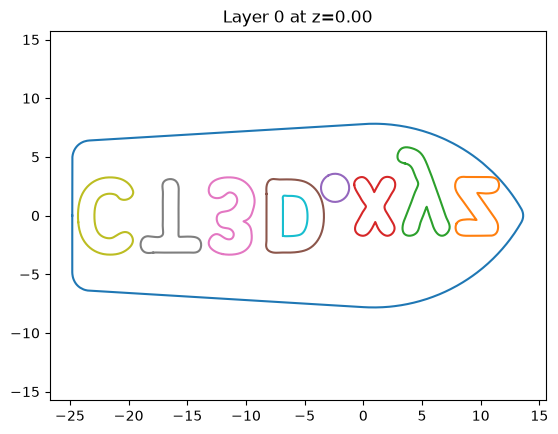

In [67]:
import numpy as np
import trimesh

slices = []

SLICE_EPSILON = 1e-3
CONTOUR_TOLERANCE = 1e-6


class Slice:
    def __init__(self):
        self.contours = []

        self.layer_number = len(slices)
        self.z_height = self.layer_number * LAYER_HEIGHT

    def display_slice(self):
        for contour in self.contours:
            line = contour.get_points()[:, :2]
            pyplot.plot(line[:, 0], line[:, 1])

        pyplot.title(
            f"Layer {self.layer_number} "
            f"at z={self.z_height:.2f}"
        )
        pyplot.axis("equal")
        pyplot.show()

    def get_contours(self):
        return self.contours

    def add_contour(self, contour):
        self.contours.append(contour)


class Contour:
    def __init__(self, points, type, index=None):
        self.points = np.asarray(points, dtype=float)

        if self.points.ndim != 2 or self.points.shape[0] < 2:
            raise ValueError("Invalid contour point array.")

        # Wall paths must be closed.
        if (
            type == "wall"
            and not np.allclose(
                self.points[0],
                self.points[-1],
                atol=CONTOUR_TOLERANCE,
                rtol=0,
            )
        ):
            self.points = np.vstack([
                self.points,
                self.points[0],
            ])

        self.type = type
        self.index = index

        self.slice_index = int(
            round(self.points[0, 2] / LAYER_HEIGHT)
        )

        if not 0 <= self.slice_index < len(slices):
            raise IndexError(
                f"Contour at z={self.points[0, 2]} maps to "
                f"invalid slice {self.slice_index}."
            )

        slices[self.slice_index].add_contour(self)

    def get_points(self):
        return self.points


# Build a Trimesh from the numpy-stl triangle data.
#
# Each STL triangle initially has independent vertices. Trimesh processes and
# merges them where appropriate but does not impose meshcut's strict
# "maximum two triangles per edge" assertion.
triangle_vertices = np.asarray(
    model.vectors,
    dtype=np.float64,
).reshape(-1, 3)

triangle_faces = np.arange(
    len(triangle_vertices),
    dtype=np.int64,
).reshape(-1, 3)

slice_mesh = trimesh.Trimesh(
    vertices=triangle_vertices,
    faces=triangle_faces,
    process=True,
    validate=True,
)

print("Trimesh information:")
print(f"  Faces: {len(slice_mesh.faces)}")
print(f"  Vertices: {len(slice_mesh.vertices)}")
print(f"  Watertight: {slice_mesh.is_watertight}")
print(f"  Winding consistent: {slice_mesh.is_winding_consistent}")


number_of_layers = int(
    np.ceil(
        (float(model.max_[2]) - float(model.min_[2]))
        / LAYER_HEIGHT
    )
)

# Create every Slice first so Contour can safely reference its destination.
for _ in range(number_of_layers):
    slices.append(Slice())


for i in range(number_of_layers):
    layer_z = i * LAYER_HEIGHT
    cutting_z = layer_z + SLICE_EPSILON

    section = slice_mesh.section(
        plane_origin=np.array([
            0.0,
            0.0,
            cutting_z,
        ]),
        plane_normal=np.array([
            0.0,
            0.0,
            1.0,
        ]),
    )

    if section is None:
        print(
            f"{i + 1} / {number_of_layers}: "
            "no intersection"
        )
        continue

    valid_polylines = []
    open_path_count = 0

    for path in section.discrete:
        path = np.asarray(path, dtype=float)

        if path.ndim != 2 or path.shape[0] < 3:
            continue

        # Remove repeated consecutive points.
        keep = np.r_[
            True,
            np.any(
                np.abs(np.diff(path, axis=0))
                > CONTOUR_TOLERANCE,
                axis=1,
            ),
        ]
        path = path[keep]

        if len(path) < 3:
            continue

        end_distance = np.linalg.norm(
            path[0] - path[-1]
        )

        if end_distance <= CONTOUR_TOLERANCE:
            # Make the closing point exactly equal to the first point.
            path[-1] = path[0]
        else:
            # An open section cannot define a printable enclosed region.
            open_path_count += 1
            continue

        # Store the contour at the nominal layer height rather than epsilon
        # above it.
        path[:, 2] = layer_z

        valid_polylines.append(path)

    # Process every contour simultaneously. This is important for Benchy:
    # cabin windows and other nested contours must be interpreted as holes.
    offset_lines = offset_contours(
        valid_polylines,
        OUTER_WALL_OFFSET,
        join_style="mitre",
    )

    for offset_line in offset_lines:
        offset_line = np.asarray(
            offset_line,
            dtype=float,
        )

        if len(offset_line) < 3:
            continue

        if offset_line.shape[1] == 2:
            offset_line = np.column_stack([
                offset_line,
                np.full(len(offset_line), layer_z),
            ])
        else:
            offset_line[:, 2] = layer_z

        Contour(
            offset_line,
            type="wall",
            index=0,
        )

    message = (
        f"{i + 1} / {number_of_layers}: "
        f"{len(valid_polylines)} closed contours"
    )

    if open_path_count:
        message += f", ignored {open_path_count} open paths"

    print(message)


print(len(slices), "slices generated.")

# Layer zero can occasionally be empty because the cutting plane is just
# above the build plate. Display the first layer containing a contour.
first_nonempty_layer = next(
    (
        slice_
        for slice_ in slices
        if slice_.get_contours()
    ),
    None,
)

if first_nonempty_layer is not None:
    first_nonempty_layer.display_slice()
else:
    print("No printable contours were generated.")


## Add conecentric contours for each contour in the layer (Inner walls)

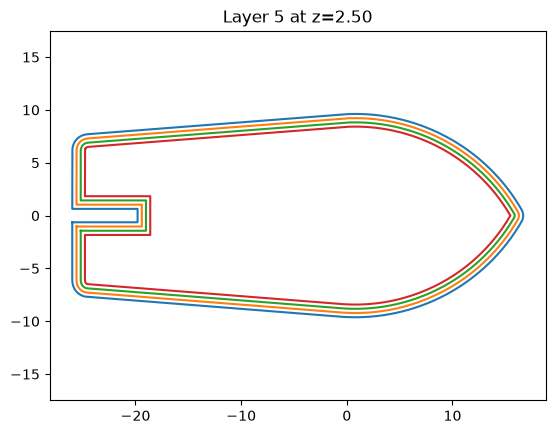

In [68]:
for slice in slices:
    contours = [
        contour for contour in slice.get_contours()
        if contour.type == "wall" and contour.index == 0
    ]
    #print(len(contours), "original contours in first slice.")

    for n in range(1, WALL_LINES):
        offset_distance = n * WALL_THICKNESS
        offset_curves = offset_contours(contours, offset_distance)
        for curve in offset_curves:
            Contour(curve, type="wall", index=n)

slices[5].display_slice()

## Identify top and bottom regions

In [69]:
# Build filled cross-sections while preserving holes.
def filled_region(contours):
    lines = []

    for contour in contours:
        points = np.asarray(contour.get_points())

        if points.ndim != 2 or len(points) < 3:
            continue

        xy = points[:, :2]

        if not np.allclose(xy[0], xy[-1]):
            xy = np.vstack([xy, xy[0]])

        lines.append(LineString(xy))

    if not lines:
        return Polygon()

    ring_polygons = []

    for line in lines:
        polygon = Polygon(line).buffer(0)

        if not polygon.is_empty:
            ring_polygons.append(polygon)

    linework = unary_union(lines)
    faces = list(polygonize(linework))

    material_faces = [
        face
        for face in faces
        if sum(
            ring.covers(face.representative_point())
            for ring in ring_polygons
        ) % 2 == 1
    ]

    if not material_faces:
        return Polygon()

    return unary_union(material_faces).buffer(0)


def polygon_parts(geometry):
    if geometry.is_empty:
        return []

    if geometry.geom_type == "Polygon":
        return [geometry]

    if geometry.geom_type == "MultiPolygon":
        return list(geometry.geoms)

    if geometry.geom_type == "GeometryCollection":
        return [
            part
            for part in geometry.geoms
            if part.geom_type == "Polygon"
        ]

    return []


def remove_small_regions(geometry, minimum_area):
    """Remove tiny disconnected regions and numerical slivers."""
    valid_parts = [
        part
        for part in polygon_parts(geometry.buffer(0))
        if part.area >= minimum_area
    ]

    if not valid_parts:
        return Polygon()

    return unary_union(valid_parts).buffer(0)


def detect_surface_region(
    current_region,
    adjacent_region,
    xy_tolerance,
    minimum_area,
):
    """
    Find genuinely exposed horizontal regions.

    adjacent_region is expanded before comparison. Consequently, small
    boundary movement caused by a sloping wall is treated as continuous
    material instead of a new top or bottom surface.
    """
    if current_region.is_empty:
        return Polygon()

    if adjacent_region.is_empty:
        exposed = current_region
    else:
        covered_region = adjacent_region.buffer(
            xy_tolerance,
            join_style="mitre",
        )

        exposed = current_region.difference(covered_region)

    exposed = remove_small_regions(
        exposed,
        minimum_area,
    )

    if exposed.is_empty:
        return Polygon()

    # Restore the detected surface towards its original boundary. The
    # tolerance is only intended for classification, not to leave gaps
    # between surface fill and the walls.
    restored = exposed.buffer(
        xy_tolerance,
        join_style="mitre",
    ).intersection(current_region)

    return remove_small_regions(
        restored,
        minimum_area,
    )


def add_surface_fill(
    geometry,
    surface_type,
    z_height,
    spacing,
    direction,
):
    """
    Generate diagonal surface lines using a global grid.

    Because the grid is anchored to the model coordinate system rather than
    the centre of each region, adjacent top and bottom regions line up.
    """
    geometry = geometry.buffer(0)

    if geometry.is_empty:
        return

    min_x, min_y, max_x, max_y = geometry.bounds

    # For positive diagonals:
    #     y - x = offset
    #
    # For negative diagonals:
    #     y + x = offset
    if direction > 0:
        minimum_offset = min_y - max_x
        maximum_offset = max_y - min_x
    else:
        minimum_offset = min_y + min_x
        maximum_offset = max_y + max_x

    # Quantise to a global grid so independently generated regions have
    # exactly the same hatch phase.
    first_offset = (
        np.floor(minimum_offset / spacing) * spacing
    )

    last_offset = (
        np.ceil(maximum_offset / spacing) * spacing
    )

    model_span = (
        max_x - min_x
        + max_y - min_y
        + 4 * spacing
    )

    offset = first_offset

    while offset <= last_offset + 0.5 * spacing:
        if direction > 0:
            # y = x + offset
            start_x = min_x - model_span
            end_x = max_x + model_span

            start = (
                start_x,
                start_x + offset,
            )

            end = (
                end_x,
                end_x + offset,
            )

        else:
            # y = -x + offset
            start_x = min_x - model_span
            end_x = max_x + model_span

            start = (
                start_x,
                -start_x + offset,
            )

            end = (
                end_x,
                -end_x + offset,
            )

        source_line = LineString([start, end])
        clipped = source_line.intersection(geometry)

        if clipped.geom_type == "LineString":
            clipped_lines = [clipped]

        elif clipped.geom_type == "MultiLineString":
            clipped_lines = list(clipped.geoms)

        elif clipped.geom_type == "GeometryCollection":
            clipped_lines = [
                part
                for part in clipped.geoms
                if part.geom_type == "LineString"
            ]

        else:
            clipped_lines = []

        for line in clipped_lines:
            if line.is_empty or len(line.coords) < 2:
                continue

            xy = np.asarray(line.coords)

            line_length = np.sum(
                np.linalg.norm(
                    np.diff(xy, axis=0),
                    axis=1,
                )
            )

            if line_length < spacing * 0.25:
                continue

            points = np.column_stack([
                xy,
                np.full(len(xy), z_height),
            ])

            Contour(
                points,
                type=surface_type,
                index=0,
            )

        offset += spacing

def get_inner_contours_for_layer(slice_):
    return [
        contour
        for contour in slice_.get_contours()
        if (
            contour.type == "wall"
            and contour.index == WALL_LINES - 1
        )
    ]


# Amount of lateral movement between adjacent layers that should still be
# interpreted as a sloping wall rather than a horizontal surface.
#
# Increase this if shallow walls are still receiving surface fill.
# Decrease it if legitimate small horizontal ledges are being missed.
SURFACE_XY_TOLERANCE = max(
    WALL_THICKNESS,
    LAYER_HEIGHT,
)

# Remove tiny pieces caused by numerical differences between layer outlines.
MINIMUM_SURFACE_AREA = max(
    WALL_THICKNESS**2,
    0.05,
)


regions = [
    filled_region(
        get_inner_contours_for_layer(slice_)
    )
    for slice_ in slices
]


# Remove results from a previous execution of this cell.
for slice_ in slices:
    slice_.contours = [
        contour
        for contour in slice_.get_contours()
        if contour.type not in {"top", "bottom"}
    ]


number_of_layers = len(slices)

raw_bottom_surfaces = [
    Polygon()
    for _ in range(number_of_layers)
]

raw_top_surfaces = [
    Polygon()
    for _ in range(number_of_layers)
]


# Detect true surface transitions.
for i, current_region in enumerate(regions):
    lower_region = (
        regions[i - 1]
        if i > 0
        else Polygon()
    )

    upper_region = (
        regions[i + 1]
        if i < number_of_layers - 1
        else Polygon()
    )

    raw_bottom_surfaces[i] = detect_surface_region(
        current_region=current_region,
        adjacent_region=lower_region,
        xy_tolerance=SURFACE_XY_TOLERANCE,
        minimum_area=MINIMUM_SURFACE_AREA,
    )

    raw_top_surfaces[i] = detect_surface_region(
        current_region=current_region,
        adjacent_region=upper_region,
        xy_tolerance=SURFACE_XY_TOLERANCE,
        minimum_area=MINIMUM_SURFACE_AREA,
    )


# Accumulate every contribution first. Do not generate hatch lines inside
# these loops, since doing that produces overlapping, discontinuous groups.
bottom_regions = [
    Polygon()
    for _ in range(number_of_layers)
]

top_regions = [
    Polygon()
    for _ in range(number_of_layers)
]


# Allow a propagated solid surface to expand laterally as the model changes
# between layers. This prevents the bottom skin retaining only the footprint
# of the smaller layer below it.
SURFACE_PROPAGATION_PER_LAYER = max(
    WALL_THICKNESS,
    LAYER_HEIGHT,
)


# Extend bottom surfaces upwards.
for source_layer, surface in enumerate(raw_bottom_surfaces):
    if surface.is_empty:
        continue

    final_layer = min(
        source_layer + BOTTOM_LAYERS,
        number_of_layers,
    )

    for target_layer in range(
        source_layer,
        final_layer,
    ):
        layer_distance = target_layer - source_layer

        expanded_surface = surface.buffer(
            layer_distance * SURFACE_PROPAGATION_PER_LAYER,
            join_style="mitre",
        )

        contribution = expanded_surface.intersection(
            regions[target_layer]
        )

        bottom_regions[target_layer] = unary_union([
            bottom_regions[target_layer],
            contribution,
        ]).buffer(0)


# Extend top surfaces downwards.
for source_layer, surface in enumerate(raw_top_surfaces):
    if surface.is_empty:
        continue

    first_layer = max(
        0,
        source_layer - TOP_LAYERS + 1,
    )

    for target_layer in range(
        first_layer,
        source_layer + 1,
    ):
        layer_distance = source_layer - target_layer

        expanded_surface = surface.buffer(
            layer_distance * SURFACE_PROPAGATION_PER_LAYER,
            join_style="mitre",
        )

        contribution = expanded_surface.intersection(
            regions[target_layer]
        )

        top_regions[target_layer] = unary_union([
            top_regions[target_layer],
            contribution,
        ]).buffer(0)


# Final cleanup, overlap removal and hatch generation.
surface_regions = [
    Polygon()
    for _ in range(number_of_layers)
]


for layer in range(number_of_layers):
    bottom_region = remove_small_regions(
        bottom_regions[layer],
        MINIMUM_SURFACE_AREA,
    )

    top_region = remove_small_regions(
        top_regions[layer],
        MINIMUM_SURFACE_AREA,
    )

    # Assign overlapping thin sections to the bottom region so they are
    # printed exactly once.
    top_region = remove_small_regions(
        top_region.difference(bottom_region),
        MINIMUM_SURFACE_AREA,
    )

    surface_regions[layer] = unary_union([
        bottom_region,
        top_region,
    ]).buffer(0)

    hatch_direction = (
        1 if layer % 2 == 0 else -1
    )

    # Use a common spacing on both types. Since the lines are now globally
    # anchored, they will meet without a phase discontinuity.
    surface_spacing = min(
        TOP_LAYER_THICKNESS,
        BOTTOM_LAYER_THICKNESS,
    )

    add_surface_fill(
        bottom_region,
        "bottom",
        slices[layer].z_height,
        surface_spacing,
        hatch_direction,
    )

    add_surface_fill(
        top_region,
        "top",
        slices[layer].z_height,
        surface_spacing,
        hatch_direction,
    )

In [70]:
# display_index = 5
# slices[display_index - 1].display_slice()
# slices[display_index].display_slice()
# slices[display_index + 1].display_slice()
# slices[display_index + 2].display_slice()

## Infill

In [71]:
# Generate normal infill only where top/bottom fill is not present.
for slice in slices:
    # Remove infill from an earlier execution so rerunning this cell replaces it.
    slice.contours = [
        contour for contour in slice.get_contours()
        if contour.type != "infill"
    ]

    innermost_walls = [
        contour for contour in slice.get_contours()
        if contour.type == "wall" and contour.index == WALL_LINES - 1
    ]

    # Generate a 45-degree grid pattern.
    infill_pattern = []
    for i in range(-100, 100, max(int((1 - INFILL) * 10), 1)):
        infill_pattern.append(LineString([(100, i), (i, 100)]))
        infill_pattern.append(LineString([(-i, -100), (-100, -i)]))
        infill_pattern.append(LineString([(-100, i), (-i, 100)]))
        infill_pattern.append(LineString([(i, -100), (100, -i)]))

    # Reconstruct the filled innermost region while preserving holes.
    wall_lines = [
        LineString(contour.get_points()[:, :2])
        for contour in innermost_walls
    ]
    wall_polygons = [Polygon(line) for line in wall_lines]
    wall_faces = list(polygonize(unary_union(wall_lines)))
    innermost_wall_region = unary_union([
        face for face in wall_faces
        if sum(
            polygon.covers(face.representative_point())
            for polygon in wall_polygons
        ) % 2 == 1
    ])

    # Exclude the regions already assigned to top/bottom fill on this layer.
    infill_region = innermost_wall_region.difference(
        surface_regions[slice.layer_number]
    )

    # Clip each source line separately so crossings do not split toolpaths.
    for pattern_line in infill_pattern:
        clipped = pattern_line.intersection(infill_region)
        if clipped.is_empty:
            continue

        if clipped.geom_type == "LineString":
            clipped_lines = [clipped]
        elif clipped.geom_type == "MultiLineString":
            clipped_lines = list(clipped.geoms)
        elif clipped.geom_type == "GeometryCollection":
            clipped_lines = [
                geom for geom in clipped.geoms
                if geom.geom_type == "LineString"
            ]
        else:
            clipped_lines = []

        for line in clipped_lines:
            if line.is_empty or len(line.coords) < 2:
                continue
            points = np.column_stack([
                np.asarray(line.coords),
                np.full(len(line.coords), slice.z_height),
            ])
            Contour(points, type="infill", index=0)


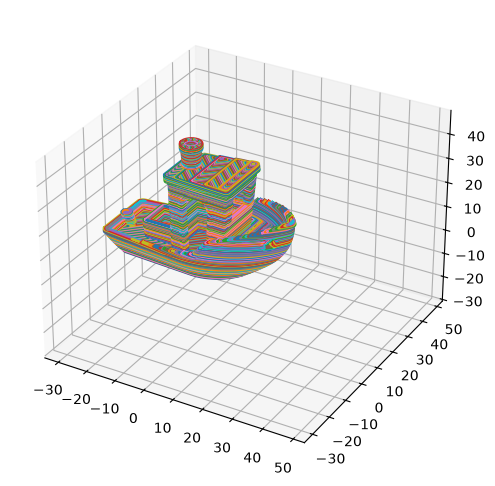

In [ ]:
# slices[14].display_slice()
# slices[15].display_slice()
# slices[16].display_slice()
# slices[17].display_slice()
# slices[18].display_slice()



# 3d visualization of the generated slices
figure = pyplot.figure(figsize=(8, 6))
plot_axes = figure.add_subplot(projection='3d')

for slice in slices:
    for contour in slice.get_contours():
        points = contour.get_points()
        plot_axes.plot(points[:, 0], points[:, 1], points[:, 2])

scale = slice_mesh.vertices.flatten()
plot_axes.auto_scale_xyz(scale, scale, scale)
pyplot.show()

for i in range(0, len(slices), 1):
    slices[i].display_slice()